In [10]:
import pytest
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

class DataProcessor:
    def __init__(self, file_path):
        self.data = pd.read_csv(file_path, sep=',')
        self.new_column_names = [
            'area', 'rooms', 'floor', 'total_floor', 'year_built', 'attic', 'dish_washer', 'fridge', 'furniture',
            'oven', 'stove', 'tv', 'washer', 'secure_doors_windows', 'videophone', 'monitoring',
            'closed_area', 'balcony', 'basement', 'parking_space', 'alarm_system', 'for_non_smokers',
            'anti_burglary_blinds', 'elevator', 'separate_kitchen', 'internet', 'cable_tv', 'telephone', 'air_conditioning',
            'for_students', 'utility_room', 'terrace', 'two_level', 'garden', 'b_type_apartment',
            'b_type_panel', 'b_type_infill','b_type_loft', 'b_type_row',
            'b_type_detached', 'b_type_tenement', 'b_mat_aerated_concrete',
            'b_mat_brick', 'b_mat_concreate', 'b_mat_hollow_block', 'b_mat_large_panel','b_mat_expanded_clay',
            'b_mat_other', 'b_mat_reinforced_concrete', 'b_mat_silicate_brick', 'b_mat_wood',
            'windows_aluminum', 'windows_plastic', 'windows_wooden', 'heating_boiler', 'heating_central', 'heating_electric',
            'heating_gas', 'heating_other', 'status_not_ready', 'status_ready', 'status_renovation',
            'district_Bemowo', 'district_Białołęka', 'district_Bielany', 'district_Centrum', 'district_Metro_Wilanowska',
            'district_Mokotów', 'district_Ochota', 'district_Praga_Południe', 'district_Praga_Północ', 'district_Rembertów',
            'district_Targówek', 'district_Ursus', 'district_Ursynów', 'district_Warszawa', 'district_Wawer', 'district_Wesoła',
            'district_Wilanów', 'district_Wola', 'district_Włochy', 'district_mazowieckie', 'district_Śródmieście',
            'district_Żoliborz', 'gross_price'
        ]

    def clean_data(self):
        self.data.columns = self.new_column_names

        # Usuwanie niepotrzebnych kolumn
        self.data.drop(columns=['b_mat_aerated_concrete', 'b_mat_brick', 'b_mat_concreate', 'b_mat_hollow_block',
                                'b_mat_large_panel', 'b_mat_expanded_clay', 'b_mat_other', 'b_mat_reinforced_concrete',
                                'b_mat_silicate_brick', 'b_mat_wood', 'secure_doors_windows', 'for_non_smokers', 'for_students',
                                'anti_burglary_blinds', 'telephone', 'status_not_ready', 'status_ready', 'status_renovation'],
                       inplace=True)

        # Konwersja kolumn na typ int
        columns_to_convert = [col for col in self.data.columns if col != 'gross_price']
        self.data[columns_to_convert] = self.data[columns_to_convert].astype(int)

    def handle_outliers(self):
        def detect_outliers(df, column):
            Q1 = df[column].quantile(0.25)
            Q3 = df[column].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            return lower_bound, upper_bound

        # Detekcja wartości odstających
        area_lower, area_upper = detect_outliers(self.data, "area")
        price_lower, price_upper = detect_outliers(self.data, "gross_price")

        # Oznaczanie wartości odstających jako NaN
        self.data.loc[(self.data['area'] < area_lower) | (self.data['area'] > area_upper), 'area'] = np.nan
        self.data.loc[(self.data['gross_price'] < price_lower) | (self.data['gross_price'] > price_upper), 'gross_price'] = np.nan

        # Usuwanie wierszy z NaN
        self.data.dropna(inplace=True)

    def scale_data(self):
        scaler = StandardScaler()
        columns_to_scale = ['area', 'rooms', 'floor', 'total_floor', 'year_built']
        self.data[columns_to_scale] = scaler.fit_transform(self.data[columns_to_scale])

        return scaler

class BuildingTypeVectorizer:
    def __init__(self):
        # Lista wszystkich możliwych kategorii typu budynku
        self.categories = ['apartment', 'panel', 'infill', 'loft', 'row', 'detached', 'tenement']

    def fit(self, X):
        pass

    def transform(self, X):
        # Wykonanie kodowania one-hot dla atrybutu 'building_type'
        one_hot = pd.get_dummies(X['building_type'], prefix='b_type')

        # Upewnij się, że wszystkie kategorie są obecne w wynikowym DataFrame
        for category in self.categories:
            col_name = f'b_type_{category}'
            if col_name not in one_hot.columns:
                one_hot[col_name] = 0

        # Ustawienie kolumn w określonej kolejności
        one_hot = one_hot[[f'b_type_{cat}' for cat in self.categories]]

        return one_hot

    def fit_transform(self, X):

        self.fit(X)
        return self.transform(X)

class ModelTrainer:
    def __init__(self, X_train, y_train, X_test, y_test):
        self.X_train = X_train
        self.y_train = y_train
        self.X_test = X_test
        self.y_test = y_test
        self.models = {
            'lr': LinearRegression(),
            'rf': RandomForestRegressor(random_state=42),
            'xgb': xgb.XGBRegressor(objective='reg:squarederror', random_state=42)
        }

    def train_models(self):
        results = {}
        y_preds = {}
        for name, model in self.models.items():
            model.fit(self.X_train, self.y_train)
            y_pred = model.predict(self.X_test)
            y_preds[name] = y_pred
            mae = mean_absolute_error(self.y_test, y_pred)
            mse = mean_squared_error(self.y_test, y_pred)
            rmse = np.sqrt(mse)
            r2 = r2_score(self.y_test, y_pred)
            results[name] = {'mae': mae, 'mse': mse, 'rmse': rmse, 'r2': r2}

        return results, y_preds

    def hyperparameter_tuning(self, param_grid):
        grid_results = {}
        y_preds = {}
        for name, model in self.models.items():
            grid_search = GridSearchCV(model, param_grid[name], cv=5)
            grid_search.fit(self.X_train, self.y_train)
            y_pred = grid_search.predict(self.X_test)
            y_preds[name] = y_pred
            mae = mean_absolute_error(self.y_test, y_pred)
            mse = mean_squared_error(self.y_test, y_pred)
            rmse = np.sqrt(mse)
            r2 = r2_score(self.y_test, y_pred)
            grid_results[name] = {'mae': mae, 'mse': mse, 'rmse': rmse, 'r2': r2}

        return grid_results, y_preds

class DataVisualizer:
    def __init__(self, data):
        self.data = data

    def plot_correlation_matrix(self, top_columns):
        correlation = self.data[top_columns].corr()
        colormap = sns.color_palette("BrBG", 10)
        plt.figure(figsize=(10, 6))
        sns.heatmap(correlation, annot=True, cmap=colormap, fmt=".2f")
        plt.title("Macierz korelacji")
        plt.show()

    def plot_histograms(self, columns):
        for column in columns:
            plt.figure(figsize=(8, 5))
            sns.histplot(self.data[column], bins=30, kde=True, color='yellow')
            plt.title(f"Histogram dla {column}")
            plt.xlabel(column)
            plt.ylabel("Częstość")
            plt.show()


class TestModelPipeline:
    @pytest.fixture(scope='module')
    def load_data(self):
        #Fixture do wczytania i przetworzenia danych
        df = pd.read_csv('C:\\Users\\czern\\OneDrive\\Документы\\уник\\uczenie maszynowe проект\\data_clean.csv', sep=',')
        df.dropna(inplace=True)  # Powtarzamy przetwarzanie na danych
        X = df.drop(columns=['gross_price'])
        y = df['gross_price']
        return X, y

    @pytest.fixture(scope='module')
    def load_scaler_model(self):
        #Fixture do wczytania skalera i modelu
        with open('scaler.pkl', 'rb') as f:
            scaler = pickle.load(f)
        with open('model_xgb.pkl', 'rb') as f:
            model = pickle.load(f)
        return scaler, model

    def test_data_shape(self, load_data):
        #Sprawdzamy, czy dane nie są puste i mają poprawny kształt
        X, y = load_data
        assert not X.empty, "Zbiór danych X jest pusty."
        assert y.size > 0, "Kolumna y (gross_price) jest pusta."
        assert X.shape[0] == y.size, "Liczba próbek w X i y powinna być równa."

    def test_scaler_output(self, load_data, load_scaler_model):
        #Sprawdzamy, czy scaler prawidłowo przetwarza dane
        X, _ = load_data
        scaler, _ = load_scaler_model
        columns_to_scale = ['area', 'rooms', 'floor', 'total_floor', 'year_built']
        X_scaled = X.copy()
        X_scaled[columns_to_scale] = scaler.transform(X[columns_to_scale])
        assert np.allclose(X_scaled[columns_to_scale].mean(), 0, atol=1e-2), "Średnia po skalowaniu nie jest bliska 0."
        assert np.allclose(X_scaled[columns_to_scale].std(), 1, atol=1e-2), "Odchylenie standardowe po skalowaniu nie jest bliskie 1."

    def test_model_predictions(self, load_data, load_scaler_model):
        #Sprawdzamy, czy model generuje przewidywania o poprawnym kształcie
        X, _ = load_data
        scaler, model = load_scaler_model
        columns_to_scale = ['area', 'rooms', 'floor', 'total_floor', 'year_built']
        X_scaled = X.copy()
        X_scaled[columns_to_scale] = scaler.transform(X[columns_to_scale])
        preds = model.predict(X_scaled)
        assert len(preds) == len(X), "Długość przewidywań powinna być taka sama jak liczba wierszy w danych wejściowych."
        assert isinstance(preds, np.ndarray), "Przewidywania modelu powinny być typu np.ndarray."

    def test_single_prediction(self, load_scaler_model):
        single_input = {
            'area': 51.0,
            'rooms': 2,
            'floor': 2,
            'total_floor': 5,
            'year_built': 2013,
            'attic': 0,
            'dish_washer': 1,
            'fridge': 1,
            'furniture': 1,
            'oven': 1,
            'stove': 1,
            'tv': 1,
            'washer': 1,
            'videophone': 1,
            'monitoring': 1,
            'closed_area': 1,
            'balcony': 1,
            'basement': 0,
            'parking_space': 1,
            'alarm_system': 0,
            'elevator': 0,
            'separate_kitchen': 1,
            'internet': 0,
            'cable_tv': 1,
            'air_conditioning': 0,
            'utility_room': 0,
            'terrace': 0,
            'two_level': 0,
            'garden': 0,
            'b_type_apartment': 1,
            'b_type_panel': 0,
            'b_type_infill': 0,
            'b_type_loft': 0,
            'b_type_row': 0,
            'b_type_detached': 0,
            'b_type_tenement': 0,
            'windows_aluminum': 0,
            'windows_plastic': 1,
            'windows_wooden': 0,
            'heating_boiler': 0,
            'heating_central': 1,
            'heating_electric': 0,
            'heating_gas': 0,
            'heating_other': 0,
            'district_Bemowo': 0,
            'district_Białołęka': 0,
            'district_Bielany': 0,
            'district_Centrum': 0,
            'district_Metro_Wilanowska': 0,
            'district_Mokotów': 0,
            'district_Ochota': 1,
            'district_Praga_Południe': 0,
            'district_Praga_Północ': 0,
            'district_Rembertów': 0,
            'district_Targówek': 0,
            'district_Ursus': 0,
            'district_Ursynów': 0,
            'district_Warszawa': 0,
            'district_Wawer': 0,
            'district_Wesoła': 0,
            'district_Wilanów': 0,
            'district_Wola': 0,
            'district_Włochy': 0,
            'district_mazowieckie': 0,
            'district_Śródmieście': 0,
            'district_Żoliborz': 0
        }
        scaler, model = load_scaler_model
        single_df = pd.DataFrame([single_input])

        # Skalowanie danych
        columns_to_scale = ['area', 'rooms', 'floor', 'total_floor', 'year_built']
        single_scaled = single_df.copy()
        single_scaled[columns_to_scale] = scaler.transform(single_scaled[columns_to_scale])

        # Przewidywanie
        pred_price = model.predict(single_scaled)
        assert pred_price.size == 1, "Model powinien zwracać jedną wartość dla pojedynczego wejścia."
        assert pred_price[0] > 0, "Cena nie może być ujemna ani zerowa."

In [33]:
data_processor = DataProcessor(file_path='C:\\Users\\czern\\OneDrive\\Документы\\уник\\uczenie maszynowe projekt\\data_clean.csv')

In [34]:
data_processor.data

,area,room_num,floor,total_floor,year_built,poddasze,dish_washer(zmywarka),fridge(lodówka),furniture(meble),oven(piekarnik),...,district_ Warszawa,district_ Wawer,district_ Wesoła,district_ Wilanów,district_ Wola,district_ Włochy,district_ mazowieckie,district_ Śródmieście,district_ Żoliborz,gross_price
0,37.0,2.0,1.0,4.000000,2001.453488,0.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,2435.244186
1,38.0,2.0,1.0,5.802326,2020.000000,0.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2175.000000
2,57.0,3.0,1.0,15.000000,1984.000000,0.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3300.000000
3,63.0,2.0,4.0,5.000000,2005.000000,0.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2585.046512
4,65.0,3.0,3.0,4.000000,1938.000000,0.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3424.918605
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3467,45.0,1.0,3.0,7.000000,2002.965116,0.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2350.000000
3468,50.0,2.0,1.0,2.000000,2006.000000,0.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,3737.302326
3469,46.0,2.0,5.0,5.000000,2015.000000,0.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2842.093023
3470,23.0,1.0,1.0,4.000000,1938.000000,0.0,0.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1570.000000


In [35]:
data_processor.data.head()

,area,room_num,floor,total_floor,year_built,poddasze,dish_washer(zmywarka),fridge(lodówka),furniture(meble),oven(piekarnik),...,district_ Warszawa,district_ Wawer,district_ Wesoła,district_ Wilanów,district_ Wola,district_ Włochy,district_ mazowieckie,district_ Śródmieście,district_ Żoliborz,gross_price
0,37.0,2.0,1.0,4.000000,2001.453488,0.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,2435.244186
1,38.0,2.0,1.0,5.802326,2020.000000,0.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2175.000000
2,57.0,3.0,1.0,15.000000,1984.000000,0.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3300.000000
3,63.0,2.0,4.0,5.000000,2005.000000,0.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2585.046512
4,65.0,3.0,3.0,4.000000,1938.000000,0.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3424.918605


In [36]:
data_processor.data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3472 entries, 0 to 3471
Data columns (total 85 columns):
 #   Column                                                  Non-Null Count  Dtype  
---  ------                                                  --------------  -----  
 0   area                                                    3472 non-null   float64
 1   room_num                                                3472 non-null   float64
 2   floor                                                   3472 non-null   float64
 3   total_floor                                             3472 non-null   float64
 4   year_built                                              3472 non-null   float64
 5   poddasze                                                3472 non-null   float64
 6   dish_washer(zmywarka)                                   3472 non-null   float64
 7   fridge(lodówka)                                         3472 non-null   float64
 8   furniture(meble)                      

In [37]:
data_processor.data.describe()

,area,room_num,floor,total_floor,year_built,poddasze,dish_washer(zmywarka),fridge(lodówka),furniture(meble),oven(piekarnik),...,district_ Warszawa,district_ Wawer,district_ Wesoła,district_ Wilanów,district_ Wola,district_ Włochy,district_ mazowieckie,district_ Śródmieście,district_ Żoliborz,gross_price
count,3472.000000,3472.000000,3472.000000,3472.000000,3472.000000,3472.000000,3472.000000,3472.000000,3472.000000,3472.000000,...,3472.000000,3472.000000,3472.000000,3472.000000,3472.000000,3472.000000,3472.000000,3472.000000,3472.000000,3472.000000
mean,45.457661,1.985311,3.525101,6.530389,2010.896005,0.002016,0.622120,0.971774,0.938652,0.834677,...,0.005472,0.012097,0.004032,0.036002,0.147465,0.022177,0.012673,0.098502,0.030242,2743.665343
std,17.593785,0.746499,2.612843,3.336553,353.907361,0.044863,0.484927,0.165641,0.240002,0.371525,...,0.073783,0.109334,0.063381,0.186323,0.354620,0.147281,0.111874,0.298036,0.171277,938.332497
min,3.000000,1.000000,0.000000,1.000000,1890.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,581.418605
25%,35.000000,2.000000,1.000000,4.000000,1992.000000,0.000000,0.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2200.000000
50%,42.000000,2.000000,3.000000,6.000000,2004.319767,0.000000,1.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2587.476744
75%,53.000000,2.000000,5.000000,8.000000,2017.000000,0.000000,1.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3000.000000
max,220.000000,7.000000,15.000000,30.000000,20202.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,11500.000000


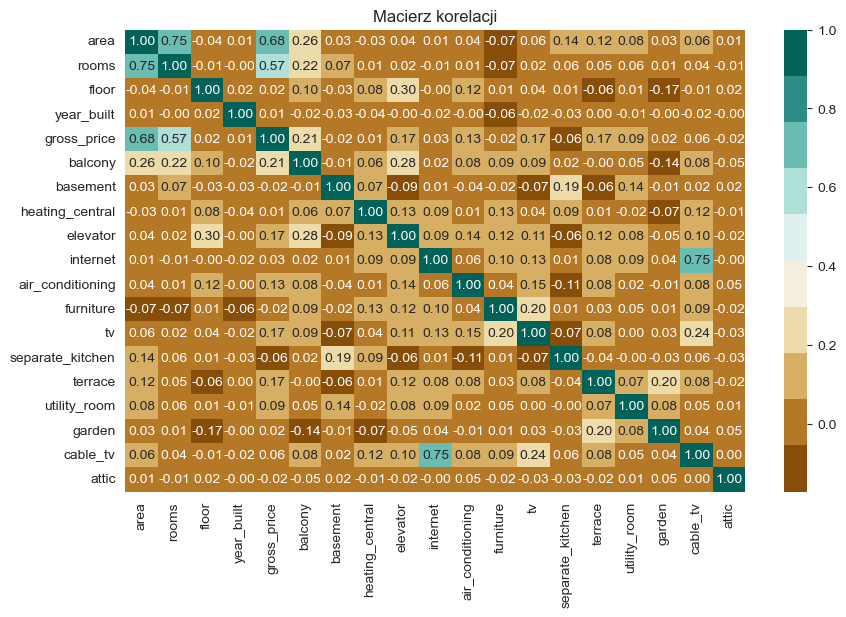

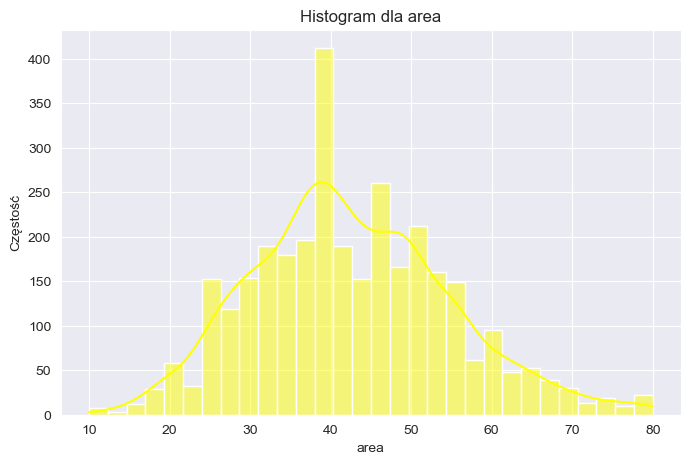

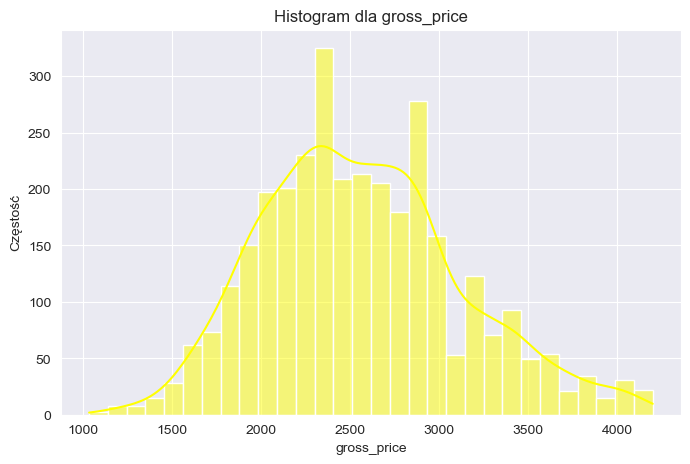

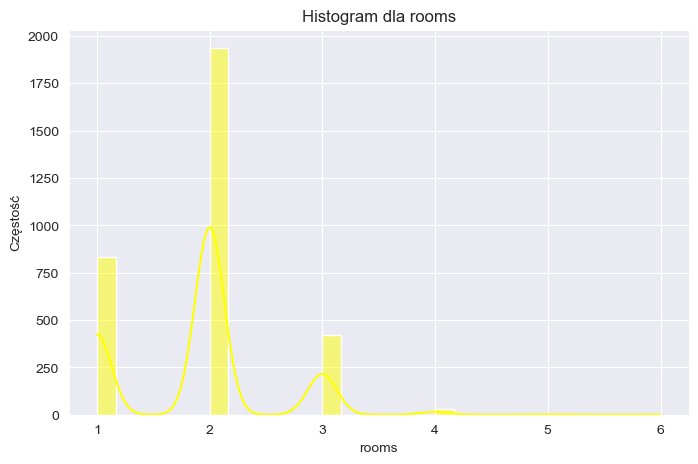

In [38]:
# 1. Czyszczenie danych
data_processor.clean_data()
data_processor.handle_outliers()
# 2. Wizualizacja danych
visualizer = DataVisualizer(data_processor.data)
visualizer.plot_correlation_matrix(top_columns=['area', 'rooms', 'floor', 'year_built', 'gross_price', 'balcony', 'basement', 'heating_central', 'elevator', 'internet', 'air_conditioning', 'furniture', 'tv', 'separate_kitchen', 'terrace', 'utility_room', 'garden', 'cable_tv', 'attic'])
visualizer.plot_histograms(columns=['area', 'gross_price', 'rooms'])

In [39]:
data_processor.data


,area,rooms,floor,total_floor,year_built,attic,dish_washer,fridge,furniture,oven,...,district_Warszawa,district_Wawer,district_Wesoła,district_Wilanów,district_Wola,district_Włochy,district_mazowieckie,district_Śródmieście,district_Żoliborz,gross_price
0,37.0,2,1,4,2001,0,1,1,1,1,...,0,0,0,0,0,1,0,0,0,2435.244186
1,38.0,2,1,5,2020,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,2175.000000
2,57.0,3,1,15,1984,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,3300.000000
3,63.0,2,4,5,2005,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,2585.046512
4,65.0,3,3,4,1938,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,3424.918605
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3467,45.0,1,3,7,2002,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,2350.000000
3468,50.0,2,1,2,2006,0,1,1,1,1,...,0,0,0,1,0,0,0,0,0,3737.302326
3469,46.0,2,5,5,2015,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,2842.093023
3470,23.0,1,1,4,1938,0,0,1,1,0,...,0,0,0,0,0,0,0,0,0,1570.000000


In [12]:
#3. Skalowanie danych
scaler = data_processor.scale_data()

In [13]:
# 4. Przygotowanie danych
X = data_processor.data.drop(columns=['gross_price'])
y = data_processor.data['gross_price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Wyniki bez optymalizacji hiperparametrów:
LR - MAE: 263.82, MSE: 118575.91, RMSE: 344.35, R²: 0.63
RF - MAE: 250.79, MSE: 111167.92, RMSE: 333.42, R²: 0.65
XGB - MAE: 254.48, MSE: 116031.17, RMSE: 340.63, R²: 0.64


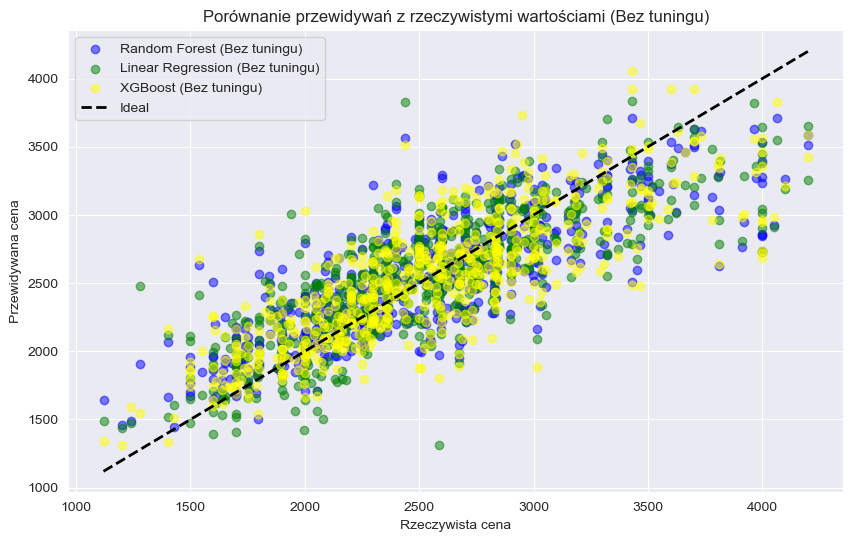

In [14]:
# 5. Trening modeli
trainer = ModelTrainer(X_train_scaled, y_train, X_test_scaled, y_test)
results, y_preds = trainer.train_models()

# Wyniki bez optymalizacji hiperparametrów
print("Wyniki bez optymalizacji hiperparametrów:")
for model, metrics in results.items():
    print(f"{model.upper()} - MAE: {metrics['mae']:.2f}, MSE: {metrics['mse']:.2f}, RMSE: {metrics['rmse']:.2f}, R²: {metrics['r2']:.2f}")

# Wykres porównania dla wyników bez tuningu
plt.figure(figsize=(10, 6))

# Rzeczywiste vs Predykcje dla Random Forest
plt.scatter(y_test, y_preds['rf'], color='blue', alpha=0.5, label='Random Forest (Bez tuningu)')

# Rzeczywiste vs Predykcje dla Linear Regression
plt.scatter(y_test, y_preds['lr'], color='green', alpha=0.5, label='Linear Regression (Bez tuningu)')

# Rzeczywiste vs Predykcje dla XGBoost
plt.scatter(y_test, y_preds['xgb'], color='yellow', alpha=0.5, label='XGBoost (Bez tuningu)')

# Idealna linia
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='Ideal')

# Tytuł i etykiety
plt.title("Porównanie przewidywań z rzeczywistymi wartościami (Bez tuningu)")
plt.xlabel("Rzeczywista cena")
plt.ylabel("Przewidywana cena")
plt.legend()
plt.show() 



Wyniki po optymalizacji hiperparametrów:
LR - MAE: 263.82, MSE: 118575.91, RMSE: 344.35, R²: 0.63
RF - MAE: 250.21, MSE: 111473.30, RMSE: 333.88, R²: 0.65
XGB - MAE: 246.81, MSE: 108532.07, RMSE: 329.44, R²: 0.66


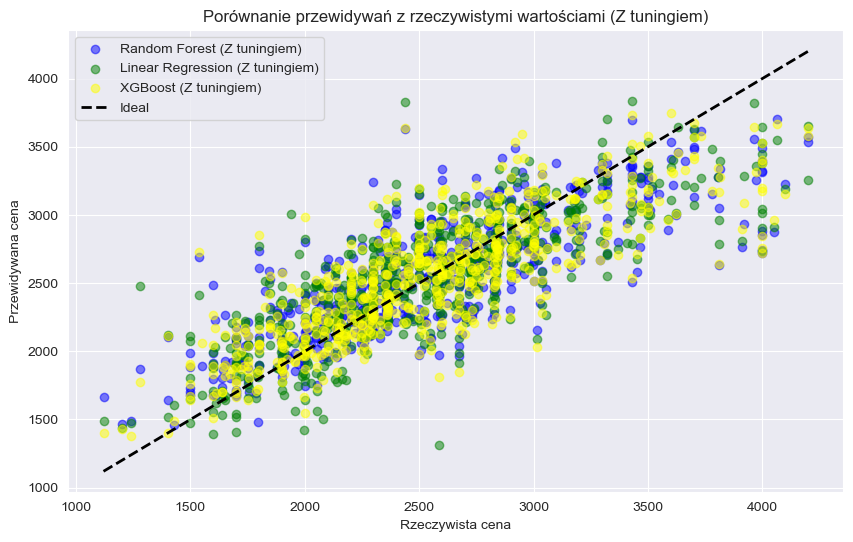

In [15]:
# 6. Optymalizacja hiperparametrów
param_grid = {
    'lr': {'fit_intercept': [True]},
    'rf': {'n_estimators': [100, 200, 300], 'max_depth': [10, 20, None]},
    'xgb': {'n_estimators': [100, 200], 'learning_rate': [0.01, 0.1, 0.2]}
}
grid_results, grid_y_preds = trainer.hyperparameter_tuning(param_grid)

# Wyniki po optymalizacji hiperparametrów
print("\nWyniki po optymalizacji hiperparametrów:")
for model, metrics in grid_results.items():
    print(f"{model.upper()} - MAE: {metrics['mae']:.2f}, MSE: {metrics['mse']:.2f}, RMSE: {metrics['rmse']:.2f}, R²: {metrics['r2']:.2f}")

# Wykres porównania dla wyników po tuningu
plt.figure(figsize=(10, 6))

# Rzeczywiste vs Predykcje dla Random Forest
plt.scatter(y_test, grid_y_preds['rf'], color='blue', alpha=0.5, label='Random Forest (Z tuningiem)')

# Rzeczywiste vs Predykcje dla Linear Regression
plt.scatter(y_test, grid_y_preds['lr'], color='green', alpha=0.5, label='Linear Regression (Z tuningiem)')

# Rzeczywiste vs Predykcje dla XGBoost
plt.scatter(y_test, grid_y_preds['xgb'], color='yellow', alpha=0.5, label='XGBoost (Z tuningiem)')

# Idealna linia
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='Ideal')

# Tytuł i etykiety
plt.title("Porównanie przewidywań z rzeczywistymi wartościami (Z tuningiem)")
plt.xlabel("Rzeczywista cena")
plt.ylabel("Przewidywana cena")
plt.legend()
plt.show()

In [30]:
# Wczytanie modelu i skalera
with open('scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

with open('model_xgb.pkl', 'rb') as f:
    model = pickle.load(f)

# Dane wejściowe dla pojedynczego mieszkania
single_input = {
    'area': 40.0,
    'rooms': 2,
    'floor': 3,
    'total_floor': 4,
    'year_built': 2000,
    'attic': 0,
    'dish_washer': 1,
    'fridge': 1,
    'furniture': 0,
    'oven': 1,
    'stove': 1,
    'tv': 0,
    'washer': 1,
    'videophone': 1,
    'monitoring': 1,
    'closed_area': 1,
    'balcony': 1,
    'basement': 0,
    'parking_space': 1,
    'alarm_system': 0,
    'elevator': 1,
    'separate_kitchen': 1,
    'internet': 1,
    'cable_tv': 1,
    'air_conditioning': 0,
    'utility_room': 0,
    'terrace': 0,
    'two_level': 0,
    'garden': 0,
    'b_type_apartment': 1,
    'b_type_panel': 0,
    'b_type_infill': 0,
    'b_type_loft': 0,
    'b_type_row': 0,
    'b_type_detached': 0,
    'b_type_tenement': 0,
    'windows_aluminum': 0,
    'windows_plastic': 1,
    'windows_wooden': 0,
    'heating_boiler': 1,
    'heating_central': 0,
    'heating_electric': 0,
    'heating_gas': 0,
    'heating_other': 0,
    'district_Bemowo': 0,
    'district_Białołęka': 0,
    'district_Bielany': 0,
    'district_Centrum': 0,
    'district_Metro_Wilanowska': 0,
    'district_Mokotów': 0,
    'district_Ochota': 0,
    'district_Praga_Południe': 0,
    'district_Praga_Północ': 0,
    'district_Rembertów': 0,
    'district_Targówek': 0,
    'district_Ursus': 1,
    'district_Ursynów': 0,
    'district_Warszawa': 0,
    'district_Wawer': 0,
    'district_Wesoła': 0,
    'district_Wilanów': 0,
    'district_Wola': 0,
    'district_Włochy': 0,
    'district_mazowieckie': 0,
    'district_Śródmieście': 0,
    'district_Żoliborz': 0
}

# Konwersja do DataFrame
single_df = pd.DataFrame([single_input])

# Skalowanie danych
columns_to_scale = ['area', 'rooms', 'floor', 'total_floor', 'year_built']
single_scaled = single_df.copy()
single_scaled[columns_to_scale] = scaler.transform(single_scaled[columns_to_scale])

# Przewidywanie ceny
pred_price = model.predict(single_scaled)
print(f"Przewidywana cena mieszkania: {pred_price[0]:,.2f} PLN")

Przewidywana cena mieszkania: 3,590.20 PLN
